<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Data Mining</b></center>
<center><b><h1>Task 3</b></center>
<center><b><h1>Dhairya Bhatt</b></center>
<center><b><h1>23010101023</b></center>
<pre>

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# read the csv file
df = pd.read_csv('heart.csv')

In [3]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


## 1. What are the number of missing values in each column of the dataset?

In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 2. What is the average age of patients grouped by the presence (target=1) or absence (target=0) of heart disease?

In [6]:
df.groupby('target')['age'].mean()

target
0    56.569138
1    52.408745
Name: age, dtype: float64

## 3. What are the top 3 most common chest pain types (cp) in the dataset?

In [7]:
df['cp'].value_counts().head(3)

cp
0    497
2    284
1    167
Name: count, dtype: int64

## 4. Replace all values of thal equal to 0 with NaN and count how many NaN values exist in the thal column.

In [8]:
df_copy = df.copy()
df_copy['thal'] = df['thal'].replace(0, np.nan)
df_copy['thal'].isnull().sum()

np.int64(7)

## 5. Filter and show patients whose chol (cholesterol) is greater than 300.

In [9]:
df[df['chol'] > 300]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
11,43,0,0,132,341,1,0,136,1,3.0,1,0,3,0
16,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
25,61,0,0,145,307,0,0,146,1,1.0,1,0,3,0
27,58,0,1,136,319,1,0,152,0,0.0,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
998,42,1,0,136,315,0,1,125,1,1.8,1,0,1,0
1004,51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
1011,45,1,1,128,308,0,0,170,0,0.0,2,0,2,1


## 6. Find the average cholesterol (chol) levels for each chest pain type (cp). Then, identify which chest pain type is associated with the highest average cholesterol level.

In [10]:
avg_chol_by_cp = df.groupby('cp')['chol'].mean()

max_cp_type = avg_chol_by_cp.idxmax()
max_cp_value = avg_chol_by_cp.max()

print("Average cholesterol by chest pain type:\n", avg_chol_by_cp)
print(f"\nChest pain type {max_cp_type} has the highest average cholesterol: {max_cp_value:.2f}")

Average cholesterol by chest pain type:
 cp
0    249.993964
1    244.700599
2    242.197183
3    237.064935
Name: chol, dtype: float64

Chest pain type 0 has the highest average cholesterol: 249.99


## 7. Normalize the oldpeak column using Min-Max scaling and store it in a new column.

In [13]:
df['oldpeak_normalized'] = (df['oldpeak'] - df['oldpeak'].min()) / (df['oldpeak'].max() - df['oldpeak'].min())
df[['oldpeak', 'oldpeak_normalized']].head()

,oldpeak,oldpeak_normalized
0,1.0,0.161290
1,3.1,0.500000
2,2.6,0.419355
3,0.0,0.000000
4,1.9,0.306452


## 8. Get the correlation matrix of all numerical columns and identify the strongest positive and negative correlations.

In [4]:
corr = df.corr(numeric_only=True)
print("Strongest Positive:", flat.idxmax(), flat.max())
print("Strongest Negative:", flat.idxmin(), flat.min())

Strongest Positive: ('cp', 'target') 0.434854250052737
Strongest Negative: ('oldpeak', 'slope') -0.575188536437517


## 9. Drop duplicate records if any exist and report how many were dropped.

In [15]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print("Duplicates removed:", before - after)

Duplicates removed: 723


## 10. Convert the sex, cp, and thal columns into categorical dtype and verify the changes.

In [16]:
df['sex'] = df['sex'].astype('category')
df['cp'] = df['cp'].astype('category')
df['thal'] = df['thal'].astype('category')
print(df[['sex', 'cp', 'thal']].dtypes)

sex     category
cp      category
thal    category
dtype: object


C:\Users\dhair\AppData\Local\Temp\ipykernel_7580\2785251033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sex'] = df['sex'].astype('category')
C:\Users\dhair\AppData\Local\Temp\ipykernel_7580\2785251033.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cp'] = df['cp'].astype('category')
C:\Users\dhair\AppData\Local\Temp\ipykernel_7580\2785251033.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value in

## 11. Compute the mean, median, and standard deviation of the age column.

In [17]:
print("Mean:", df.age.mean(), "Median:", df.age.median(), "Std:", df.age.std())

Mean: 54.420529801324506 Median: 55.5 Std: 9.047969746247457


## 12. Identify the index positions where trestbps is greater than 180.

In [22]:
print(np.where(df['trestbps'].to_numpy() > 180)[0])

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,oldpeak_normalized
151,54,1,1,192,283,0,0,195,0,0.0,2,1,3,0,0.000000
175,56,0,0,200,288,1,0,133,1,4.0,0,2,3,0,0.645161


## 13. Create a NumPy array of shape (1025, 3) containing only age, chol, and thalach, and compute the row-wise mean.

In [25]:
subset = np.array(df[['age', 'chol', 'thalach']])
np.mean(subset, axis=1)

array([144.        , 137.        , 123.        , 141.66666667,
       154.        , 142.66666667, 172.        , 163.        ,
       146.33333333, 152.        , 115.        , 173.33333333,
       145.33333333, 157.        , 137.33333333, 167.        ,
       143.        , 152.        , 144.66666667, 133.33333333,
       144.        , 133.66666667, 162.33333333, 141.33333333,
       171.33333333, 152.        , 176.33333333, 151.33333333,
       166.33333333, 119.        , 101.        , 150.33333333,
       136.33333333, 141.33333333, 129.66666667, 170.66666667,
       144.        , 145.33333333, 192.        , 153.        ,
       186.66666667, 187.66666667, 148.66666667, 125.33333333,
       153.        , 165.33333333, 150.        , 167.66666667,
       140.33333333, 128.66666667, 125.33333333, 127.66666667,
       137.        , 157.66666667, 143.        , 151.        ,
       145.        , 163.66666667, 142.66666667, 168.66666667,
       134.        , 160.66666667, 140.66666667, 123.66

## 14. Replace all values in the chol column that are greater than 400 with the mean of the column.

In [26]:
chol_mean = df['chol'].mean()
chol_modified = df['chol'].where(df['chol'] <= 400, other=chol_mean)
chol_modified[df['chol'] > 400].head()

123    246.5
158    246.5
179    246.5
450    246.5
Name: chol, dtype: float64

## 15. Count the number of patients where thalach (max heart rate) is above the overall mean.

In [27]:
thalach_mean = df['thalach'].mean()
count = (df['thalach'] > thalach_mean).sum()
print(count)

170


## 16. Calculate the z-score normalization of the oldpeak column.

In [28]:
oldpeak_mean = df['oldpeak'].mean()
oldpeak_std = df['oldpeak'].std()
zscore_oldpeak = (df['oldpeak'] - oldpeak_mean) / oldpeak_std
zscore_oldpeak.head()

0   -0.037063
1    1.771019
2    1.340523
3   -0.898054
4    0.737829
Name: oldpeak, dtype: float64

## 17. Find the top 5 rows with the highest chol values.

In [34]:
df['chol'].sort_values(ascending=False).head(5)

158    564
123    417
179    409
450    407
255    394
Name: chol, dtype: int64

## 18. Get all records where sex=1 and target=1.

In [35]:
df[(df['sex'] == 1) & (df['target'] == 1)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,oldpeak_normalized
19,58,1,2,140,211,1,0,165,0,0.0,2,0,2,1,0.000000
22,45,1,0,104,208,0,0,148,1,3.0,1,0,2,1,0.483871
26,44,1,2,130,233,0,1,179,1,0.4,2,0,2,1,0.064516
34,50,1,2,129,196,0,1,163,0,0.0,2,0,2,1,0.000000
36,51,1,3,125,213,0,0,125,1,1.4,2,1,2,1,0.225806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580,46,1,1,101,197,1,1,156,0,0.0,2,0,3,1,0.000000
582,55,1,1,130,262,0,1,155,0,0.0,2,0,2,1,0.000000
616,43,1,0,115,303,0,1,181,0,1.2,1,0,2,1,0.193548
643,65,1,0,120,177,0,1,140,0,0.4,2,0,3,1,0.064516


## 19. Plot a histogram of the age column to see the age distribution.

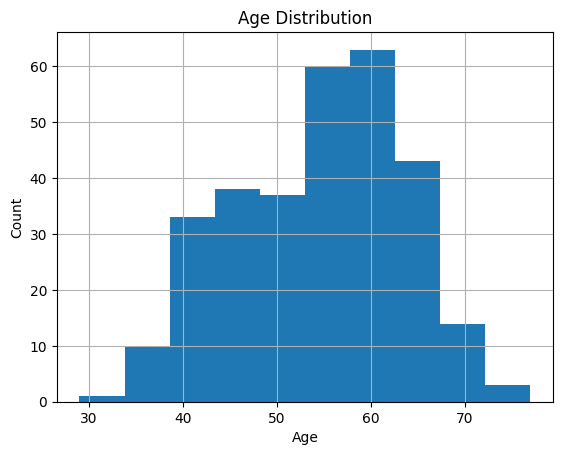

In [36]:
plt.hist(df['age'], bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## 20. Plot a bar chart showing the count of patients by cp (chest pain type).

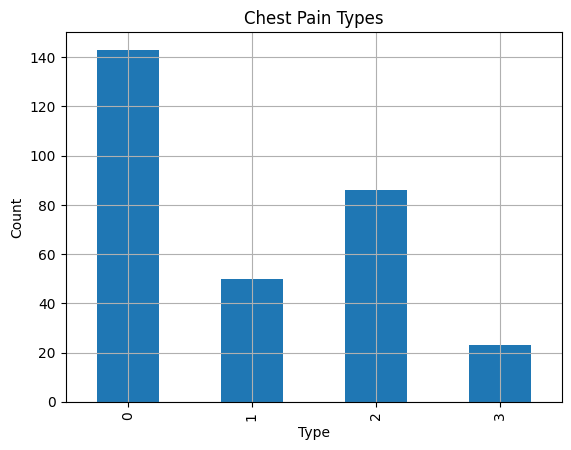

In [39]:
df['cp'].value_counts().sort_index().plot(kind='bar')
plt.title('Chest Pain Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## 21. Plot a pie chart of the gender distribution in the dataset.

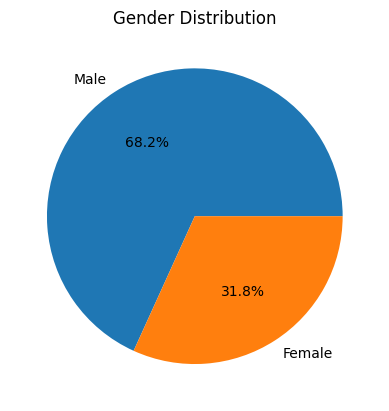

In [40]:
df['sex'].value_counts().plot(kind='pie', labels=['Male', 'Female'], autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.ylabel('')
plt.show()

## 22. Plot a box plot of chol values grouped by target (presence of heart disease).

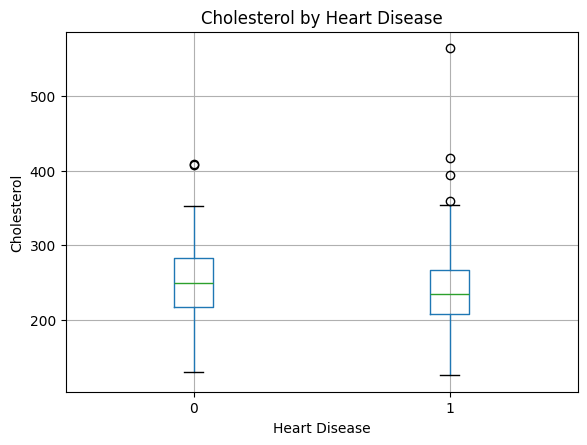

In [41]:
df.boxplot(column='chol', by='target')
plt.title('Cholesterol by Heart Disease')
plt.suptitle('')
plt.xlabel('Heart Disease')
plt.ylabel('Cholesterol')
plt.grid(True)
plt.show()

## 23. Plot a line graph of age vs. thalach to observe the relationship.

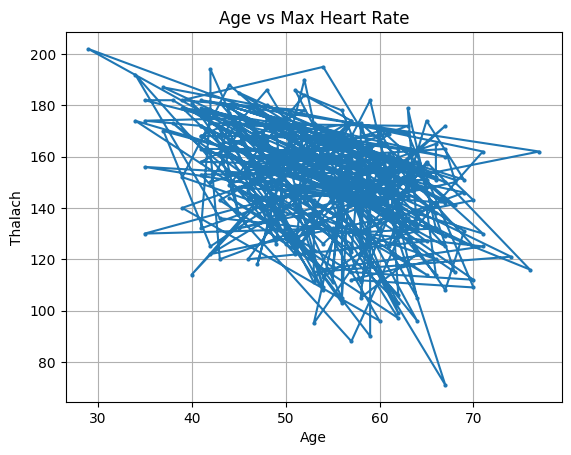

In [42]:
plt.plot(df['age'], df['thalach'], marker='o', linestyle='-', markersize=2)
plt.title('Age vs Max Heart Rate')
plt.xlabel('Age')
plt.ylabel('Thalach')
plt.grid(True)
plt.show()

## 24. Create a scatter plot of oldpeak vs. thalach and color the points based on the target value.

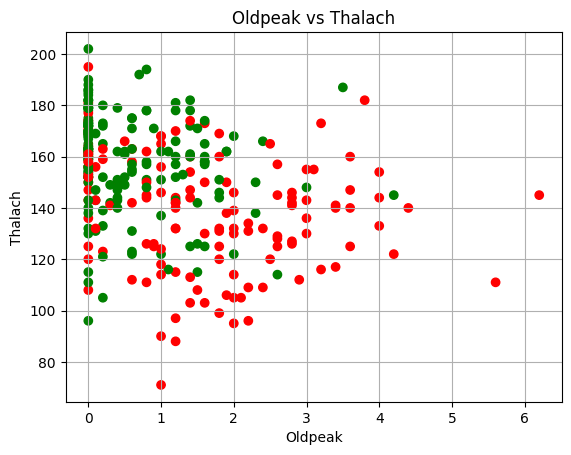

In [43]:
colors = df['target'].map({0: 'red', 1: 'green'})
plt.scatter(df['oldpeak'], df['thalach'], c=colors)
plt.title('Oldpeak vs Thalach')
plt.xlabel('Oldpeak')
plt.ylabel('Thalach')
plt.grid(True)
plt.show()

## 25. Plot a pie chart showing the proportion of patients with heart disease (target == 1) and without heart disease (target == 0).

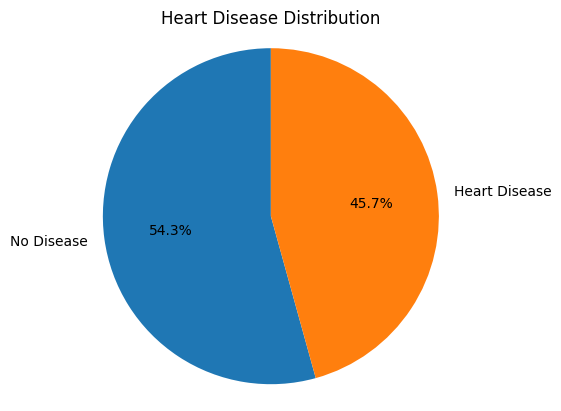

In [45]:
target_counts = df['target'].value_counts()
plt.pie(target_counts, labels=['No Disease', 'Heart Disease'], autopct='%1.1f%%', startangle=90)
plt.title('Heart Disease Distribution')
plt.axis('equal')
plt.show()